In [41]:
import requests,json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
with open ("C:/Users/User/Documents/Desktop/Ugandan_comments.json", 'r', encoding='utf-8') as file:
    data = json.load(file)

In [7]:
#Checking the type of data
if isinstance(data, list):
    comments_list = data
    print("Data is a list")
elif isinstance(data, dict) and 'comments' in data:
    comments_list = data['comments']
    print("Data is a dictionary")
else:
    comments_list = data

df = pd.DataFrame(comments_list)

print(f"\n DataFrame created with {df.shape} rows and columns")
print(f"\n Columns: {df.columns.tolist()}")
print(df.head())

Data is a list

 DataFrame created with (3969, 17) rows and columns

 Columns: ['videoWebUrl', 'submittedVideoUrl', 'input', 'cid', 'createTime', 'createTimeISO', 'text', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'repliesToId', 'replyCommentTotal', 'uid', 'uniqueId', 'avatarThumbnail', 'mentions', 'detailedMentions']
                                         videoWebUrl  \
0  https://www.tiktok.com/@eazitoncruise/video/74...   
1  https://www.tiktok.com/@eazitoncruise/video/74...   
2  https://www.tiktok.com/@eazitoncruise/video/74...   
3  https://www.tiktok.com/@eazitoncruise/video/74...   
4  https://www.tiktok.com/@eazitoncruise/video/74...   

                                   submittedVideoUrl  \
0  https://www.tiktok.com/@eazitoncruise/video/74...   
1  https://www.tiktok.com/@eazitoncruise/video/74...   
2  https://www.tiktok.com/@eazitoncruise/video/74...   
3  https://www.tiktok.com/@eazitoncruise/video/74...   
4  https://www.tiktok.com/@eazitoncruise/video/74...   

 

In [21]:
df.head()
df['text'].head(10)

0    Uganda has the best food in the world... there...
1    I love this Uganda, am not going back again to...
2    who will welcome me to Uganda please I am plan...
3    how about Uganda women ☺️☺️.... that's why I'm...
4    Am planning to visit uganda.....can l get a ug...
5                        their ladies are so sweet 😂😂😂
6    Our food is not contaminated ma we eat only fr...
7    am dating one lady from ibo in Nigeria 🇳🇬 am p...
8                      Ekiibi mwefula abatumanyi enyo😏
9    Uganda girls are so beautiful and there night ...
Name: text, dtype: object

In [23]:
slang_map = {
    'u': 'you', 'ur': 'your', 'r': 'are', 'yall': 'you all',
    'ya': 'you', 'yh': 'yeah', 'yep': 'yes', 'nope': 'no',
    'coz': 'because', 'wanna': 'want to', 'gonna': 'going to',
    'hv': 'have', 'fam': 'friend',
    # add more if needed
}

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    # remove emojis
    emoji_pattern = re.compile("["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    # special spaces
    special_spaces = re.compile(r'[\u115F\u1160\u3164\uFFA0\u200B-\u200F\u2028-\u202F\u205F\u3000]')
    text = special_spaces.sub(r' ', text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    mapped_words = [slang_map.get(word, word) for word in words]
    return ' '.join(mapped_words)

df['clean_text'] = df['text'].apply(clean_text)

In [25]:
def clean_for_sentiment(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'\[.*?\]', '', text)
    special_spaces = re.compile(r'[\u115F\u1160\u3164\uFFA0\u200B-\u200F\u2028-\u202F\u205F\u3000]')
    text = special_spaces.sub(r' ', text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    mapped_words = [slang_map.get(word.lower(), word) for word in words]
    return ' '.join(mapped_words)

df['sentiment_text'] = df['text'].apply(clean_for_sentiment)

In [27]:
stops = set(stopwords.words('english'))
all_text = ' '.join(df['clean_text'].astype(str))
words = all_text.split()
filtered = [w.lower() for w in words if w.lower() not in stops]
freq = Counter(filtered)
print(freq.most_common(15))

[('uganda', 596), ('yes', 196), ('football', 190), ('luganda', 183), ('english', 152), ('country', 146), ('swahili', 130), ('know', 116), ('love', 113), ('biggest', 107), ('artist', 107), ('language', 105), ('president', 96), ('ugandan', 94), ('one', 94)]


In [29]:
from nltk.util import ngrams

keywords = ['uganda', 'football', 'language', 'president', 'love', 'food', 'women', 'visit']
bigram_counts = Counter()
trigram_counts = Counter()

for text in df['clean_text']:
    words = text.lower().split()
    if len(words) < 2:
        continue
    for bigram in ngrams(words, 2):
        bigram_str = ' '.join(bigram)
        if any(kw in bigram_str for kw in keywords):
            bigram_counts[bigram_str] += 1
    for trigram in ngrams(words, 3):
        trigram_str = ' '.join(trigram)
        if any(kw in trigram_str for kw in keywords):
            trigram_counts[trigram_str] += 1

print("Top 10 bigrams:")
for bg, cnt in bigram_counts.most_common(10):
    print(f"  {bg}: {cnt}")
print("\nTop 10 trigrams:")
for tg, cnt in trigram_counts.most_common(10):
    print(f"  {tg}: {cnt}")

Top 10 bigrams:
  in uganda: 129
  luganda and: 78
  uganda is: 70
  football is: 54
  official language: 44
  i love: 40
  language is: 39
  is luganda: 30
  a ugandan: 27
  to uganda: 22

Top 10 trigrams:
  luganda and english: 65
  language is luganda: 22
  uganda is the: 22
  we speak luganda: 20
  official language is: 19
  living in uganda: 17
  english and luganda: 17
  my country uganda: 15
  is luganda and: 15
  speak luganda and: 12


In [31]:
sia = SentimentIntensityAnalyzer()
df['compound'] = df['sentiment_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df['sentiment'] = df['compound'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))

print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True))

sentiment
neutral     2231
positive    1348
negative     390
Name: count, dtype: int64
sentiment
neutral     0.562106
positive    0.339632
negative    0.098262
Name: proportion, dtype: float64


In [33]:
def get_subjectivity(text):
    try:
        return TextBlob(str(text)).sentiment.subjectivity
    except:
        return 0.0

df['subjectivity'] = df['sentiment_text'].apply(get_subjectivity)
df['fact_opinion'] = df['subjectivity'].apply(lambda x: 'Fact' if x < 0.3 else ('Opinion' if x > 0.6 else 'Mixed'))
print(df['fact_opinion'].value_counts())
print(df['fact_opinion'].value_counts(normalize=True))

fact_opinion
Fact    3969
Name: count, dtype: int64
fact_opinion
Fact    1.0
Name: proportion, dtype: float64


In [35]:
kw_list = ['uganda', 'football', 'president', 'love', 'food', 'women', 'visit', 'language']
for kw in kw_list:
    mask = df['clean_text'].str.contains(kw, case=False, na=False)
    if mask.sum() > 0:
        avg = df.loc[mask, 'compound'].mean()
        print(f"'{kw}': {mask.sum()} comments, avg sentiment = {avg:.2f}")

'uganda': 956 comments, avg sentiment = 0.15
'football': 186 comments, avg sentiment = 0.13
'president': 104 comments, avg sentiment = 0.18
'love': 123 comments, avg sentiment = 0.67
'food': 66 comments, avg sentiment = 0.29
'women': 8 comments, avg sentiment = 0.07
'visit': 53 comments, avg sentiment = 0.30
'language': 130 comments, avg sentiment = 0.03


In [37]:
print("Average likes per sentiment:")
print(df.groupby('sentiment')['diggCount'].mean())
print("\nCorrelation between sentiment and likes:")
print(df[['compound', 'diggCount']].corr())

Average likes per sentiment:
sentiment
negative    20.251282
neutral      7.636934
positive    10.249258
Name: diggCount, dtype: float64

Correlation between sentiment and likes:
           compound  diggCount
compound   1.000000  -0.004713
diggCount -0.004713   1.000000


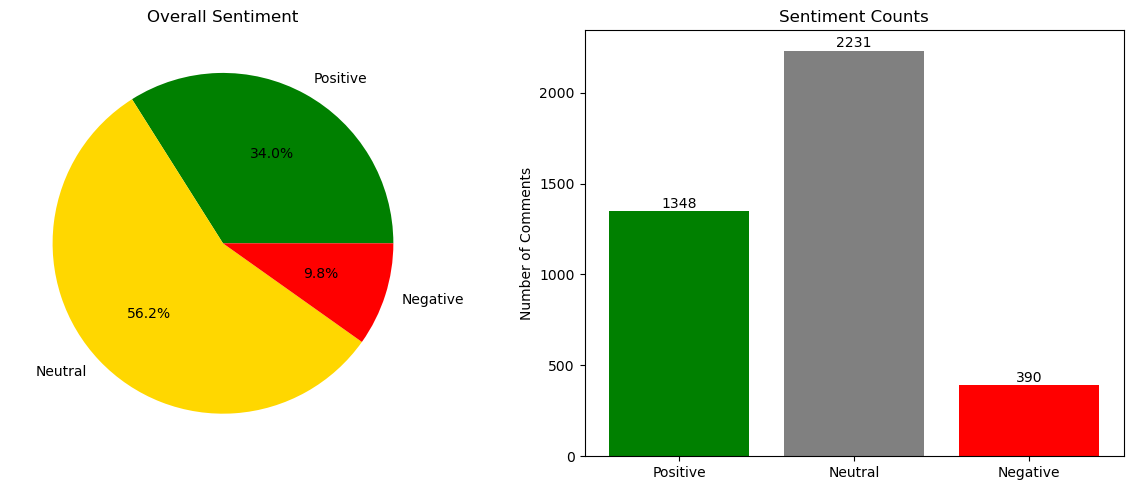

In [43]:
counts = df['sentiment'].value_counts()
pos = counts.get('positive', 0)
neu = counts.get('neutral', 0)
neg = counts.get('negative', 0)
total = pos + neu + neg

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Pie chart
axes[0].pie([pos, neu, neg], labels=['Positive', 'Neutral', 'Negative'],
            colors=['green', 'gold', 'red'], autopct='%1.1f%%')
axes[0].set_title('Overall Sentiment')

# Bar chart
axes[1].bar(['Positive', 'Neutral', 'Negative'], [pos, neu, neg],
            color=['green', 'gray', 'red'])
axes[1].set_ylabel('Number of Comments')
axes[1].set_title('Sentiment Counts')
for i, v in enumerate([pos, neu, neg]):
    axes[1].text(i, v + 20, str(v), ha='center')

plt.tight_layout()
plt.show()

In [45]:
summary = pd.DataFrame({
    'Metric': ['Total comments', 'Positive (%)', 'Neutral (%)', 'Negative (%)',
               'Strongly positive (>0.5)', 'Strongly negative (<-0.5)', 'Avg word count'],
    'Value': [
        len(df),
        f"{(pos/total)*100:.1f}%",
        f"{(neu/total)*100:.1f}%",
        f"{(neg/total)*100:.1f}%",
        (df['compound'] >= 0.5).sum(),
        (df['compound'] <= -0.5).sum(),
        f"{df['clean_text'].str.split().str.len().mean():.1f}"
    ]
})
print(summary)

                      Metric  Value
0             Total comments   3969
1               Positive (%)  34.0%
2                Neutral (%)  56.2%
3               Negative (%)   9.8%
4   Strongly positive (>0.5)    543
5  Strongly negative (<-0.5)    116
6             Avg word count    7.0
